In [1]:
### 1) Desactivar GPU y cargar librerías
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, multilabel_confusion_matrix, accuracy_score
)
import tensorflow as tf
from tensorflow.keras import layers, Model, Input, regularizers
from tensorflow.keras.metrics import BinaryAccuracy
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import tensorflow.keras.backend as K

print("Librerías cargadas. TensorFlow versión:", tf.__version__)


AttributeError: cannot import name 'float8_e3m4' from 'ml_dtypes'

In [2]:
### 2) Cargar dataset de keypoints y etiquetas (por frame)
keypoints_data = pd.read_csv(
    'D:/la-u/ciclo 2025-1/Seminario/Proyecto/csv/keypoints_final_unilado_640.csv'
)
labels_data = pd.read_csv(
    'D:/la-u/ciclo 2025-1/Seminario/Proyecto/csv/etiquetas_por_frame.csv'
)

keypoints_data['video_filename'] = keypoints_data['video_filename'].str.strip()
labels_data['video'] = labels_data['video'].str.strip()

print("✅ Datos cargados:")
print("Keypoints:", keypoints_data.shape)
print("Labels:", labels_data.shape)


✅ Datos cargados:
Keypoints: (2213079, 7)
Labels: (67063, 8)


In [3]:
### 3) Configurar columnas de landmarks y etiquetas
landmarks_to_keep = [23, 24, 25, 26, 27, 28, 29, 30, 31, 32]

error_cols = [
    'giro_incompleto',
    'pierna_patea_flexionada',
    'pierna_base_flexionada',
    'pie_sin_borde_externo',
    'preparacion_incompleta',
    'recogida_incompleta'
]
print("Etiquetas:", error_cols)


Etiquetas: ['giro_incompleto', 'pierna_patea_flexionada', 'pierna_base_flexionada', 'pie_sin_borde_externo', 'preparacion_incompleta', 'recogida_incompleta']


In [4]:
### 4) Funciones auxiliares
def angle(a, b, c):
    ba = a - b
    bc = c - b
    denom = (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
    cos = np.dot(ba, bc) / denom
    return np.degrees(np.arccos(np.clip(cos, -1, 1)))


In [5]:
### 5) Reconstruir secuencias y sincronizar con etiquetas frame a frame
video_frames = {}
video_labels = {}

for (video, frame), group in keypoints_data.groupby(['video_filename', 'frame']):
    group_sorted = group.sort_values(by='landmark_index')
    group_sorted = group_sorted[group_sorted['landmark_index'].isin(landmarks_to_keep)]
    # si falta alguno de los landmarks, saltar ese frame
    if len(group_sorted) != len(landmarks_to_keep):
        continue

    pts = group_sorted[['x','y','z']].values
    vis = group_sorted['visibility'].values[:, None]
    frame_vec = np.hstack([pts, vis]).flatten()

    idx = {lm:i for i,lm in enumerate(landmarks_to_keep)}
    L_HIP,R_HIP = pts[idx[23]], pts[idx[24]]
    L_KNEE,R_KNEE = pts[idx[25]], pts[idx[26]]
    L_ANK,R_ANK  = pts[idx[27]], pts[idx[28]]
    L_HEEL,R_HEEL= pts[idx[29]], pts[idx[30]]
    L_FI,R_FI    = pts[idx[31]], pts[idx[32]]

    ang_knee_L  = angle(L_HIP,L_KNEE,L_ANK)
    ang_knee_R  = angle(R_HIP,R_KNEE,R_ANK)
    ang_ankle_L = angle(L_KNEE,L_ANK,L_HEEL)
    ang_ankle_R = angle(R_KNEE,R_ANK,R_HEEL)

    dir_foot_L = (L_FI - L_HEEL)/(np.linalg.norm(L_FI - L_HEEL)+1e-8)
    dir_foot_R = (R_FI - R_HEEL)/(np.linalg.norm(R_FI - R_HEEL)+1e-8)

    extras = np.hstack([[ang_knee_L, ang_knee_R, ang_ankle_L, ang_ankle_R], dir_foot_L, dir_foot_R])
    feature_vec = np.concatenate([frame_vec, extras])

    video_frames.setdefault(video, []).append(feature_vec)

    # Buscar etiquetas para este frame
    label_row = labels_data[
        (labels_data['video'] == video) & (labels_data['frame'] == frame)
    ]
    if len(label_row) == 1:
        video_labels.setdefault(video, []).append(label_row[error_cols].values[0])
    else:
        video_labels.setdefault(video, []).append(np.zeros(len(error_cols)))

# Asegurarse que videos con frames vacíos se excluyan
videos_clean = [v for v in video_frames.keys() if len(video_frames[v])>0]
video_frames = {v:video_frames[v] for v in videos_clean}
video_labels = {v:video_labels[v] for v in videos_clean}

fixed_frame_count = max(len(v) for v in video_frames.values())
frame_dim = len(landmarks_to_keep)*4 + 10
print(f"Frames fijos (max por video): {fixed_frame_count}, features/frame: {frame_dim}")


Frames fijos (max por video): 162, features/frame: 50


In [6]:
### 6) Padding y armado de X, y
def pad_sequence(seq, max_len, pad_value=0.0):
    pad_size = max_len - len(seq)
    if pad_size <= 0:
        return np.array(seq[:max_len])
    pad = np.full((pad_size, seq[0].shape[-1]), pad_value)
    return np.vstack([seq, pad])

X_list, y_list, video_names = [], [], []
for video in video_frames.keys():
    X_video = pad_sequence(np.array(video_frames[video]), fixed_frame_count)
    y_video = pad_sequence(np.array(video_labels[video]), fixed_frame_count)
    X_list.append(X_video)
    y_list.append(y_video)
    video_names.append(video)

X = np.array(X_list, dtype='float32')
y = np.array(y_list, dtype='float32')

print("✅ Datos preparados:")
print("X.shape:", X.shape)
print("y.shape:", y.shape)

# Conteo por etiqueta (positivos en todo el conjunto)
for i,col in enumerate(error_cols):
    print(f"{col}: {int(y[:,:,i].sum())} frames positivos (total frames: {y.shape[0]*y.shape[1]})")


✅ Datos preparados:
X.shape: (640, 162, 50)
y.shape: (640, 162, 6)
giro_incompleto: 1622 frames positivos (total frames: 103680)
pierna_patea_flexionada: 1131 frames positivos (total frames: 103680)
pierna_base_flexionada: 1242 frames positivos (total frames: 103680)
pie_sin_borde_externo: 1112 frames positivos (total frames: 103680)
preparacion_incompleta: 1125 frames positivos (total frames: 103680)
recogida_incompleta: 1465 frames positivos (total frames: 103680)


In [7]:
### 7) Train/Val split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train:", X_train.shape, "X_val:", X_val.shape)


X_train: (512, 162, 50) X_val: (128, 162, 50)


In [8]:
### 8) Escalado preservando padding
def scale_preserving_padding(X_split):
    ns, nf, nd = X_split.shape
    X_flat = X_split.reshape(-1, nd)
    zero_rows = np.all(X_flat == 0.0, axis=1)
    scaler = StandardScaler()
    non_zero_idx = np.where(~zero_rows)[0]
    if len(non_zero_idx) == 0:
        raise ValueError("No non-zero rows found for scaling.")
    scaler.fit(X_flat[non_zero_idx])
    X_scaled_flat = scaler.transform(X_flat)
    X_scaled_flat[zero_rows] = 0.0
    return X_scaled_flat.reshape(ns, nf, nd), scaler

# Escalar train y val (manteniendo padding)
X_train_scaled, scaler = scale_preserving_padding(X_train)
X_val_scaled, _ = scale_preserving_padding(X_val)


In [9]:
### 9) Oversampling ligero de videos con positivos (duplicado simple)
# Esto intenta aumentar la proporción de secuencias con algún positivo.
pos_video_idx = [i for i in range(len(X_train_scaled)) if y_train[i].sum() > 0]
print(f"Videos en train con al menos un positivo: {len(pos_video_idx)} / {len(X_train_scaled)}")

# duplicar esas secuencias 1 vez (puedes ajustar factor)
if len(pos_video_idx) > 0:
    X_train_scaled = np.concatenate([X_train_scaled, X_train_scaled[pos_video_idx]], axis=0)
    y_train = np.concatenate([y_train, y_train[pos_video_idx]], axis=0)
    print("Oversampling aplicado. Nuevo X_train:", X_train_scaled.shape)

# Recalcular balances por etiqueta
pos_counts = np.array([y_train[:,:,i].sum() for i in range(y_train.shape[-1])], dtype=np.float32)
neg_counts = float(y_train.shape[0] * y_train.shape[1]) - pos_counts
print("Positives per label (train):", pos_counts.astype(int))


Videos en train con al menos un positivo: 415 / 512
Oversampling aplicado. Nuevo X_train: (927, 162, 50)
Positives per label (train): [2592 1774 2064 1694 1706 2260]


In [10]:
### 10) Preparar loss ponderado por etiqueta (pos_weight)
# pos_weight = n_neg / n_pos (si n_pos==0 -> 1.0)
pos_weight = []
for i in range(len(error_cols)):
    if pos_counts[i] <= 0:
        pos_weight.append(1.0)
    else:
        pos_weight.append((neg_counts[i] / (pos_counts[i] + 1e-8)).astype(np.float32))
pos_weight = np.array(pos_weight, dtype=np.float32)
print("pos_weight por etiqueta:", pos_weight)

def weighted_binary_crossentropy(pos_weight):
    # pos_weight shape: (num_labels,)
    pw = tf.constant(pos_weight, dtype=tf.float32)
    def loss(y_true, y_pred):
        # y_true/y_pred shape: (batch, timesteps, num_labels)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1-1e-7)
        # expand pw para broadcast: (1,1,num_labels)
        pw_b = tf.reshape(pw, (1,1,-1))
        loss_pos = - pw_b * y_true * tf.math.log(y_pred)
        loss_neg = - (1.0 - y_true) * tf.math.log(1.0 - y_pred)
        return tf.reduce_mean(loss_pos + loss_neg)
    return loss

# Definimos el modelo (BiLSTM) con recurrent_dropout y regularización
num_frames, num_features, num_labels = X_train_scaled.shape[1], X_train_scaled.shape[2], y_train.shape[2]

input_seq = Input(shape=(num_frames, num_features))
mask = layers.Masking(mask_value=0.0)(input_seq)

x = layers.Bidirectional(
        layers.LSTM(256, return_sequences=True, kernel_regularizer=regularizers.l2(1e-3),
                    dropout=0.2, recurrent_dropout=0.2)
    )(mask)
x = layers.Dropout(0.4)(x)
x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True, kernel_regularizer=regularizers.l2(1e-3),
                    dropout=0.2, recurrent_dropout=0.2)
    )(x)
x = layers.Dropout(0.4)(x)
x = layers.TimeDistributed(layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-3)))(x)
x = layers.Dropout(0.4)(x)
output = layers.TimeDistributed(layers.Dense(num_labels, activation='sigmoid'))(x)

model = Model(input_seq, output)
model.compile(optimizer='adam', loss=weighted_binary_crossentropy(pos_weight), metrics=[BinaryAccuracy(name='bin_acc')])
model.summary()


pos_weight por etiqueta: [56.9375  83.65276 71.75872 87.65053 87.02696 65.44867]


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 162, 50)]         0         
                                                                 
 masking (Masking)           (None, 162, 50)           0         
                                                                 
 bidirectional (Bidirection  (None, 162, 512)          628736    
 al)                                                             
                                                                 
 dropout (Dropout)           (None, 162, 512)          0         
                                                                 
 bidirectional_1 (Bidirecti  (None, 162, 256)          656384    
 onal)                                                           
                                            

Epoch 1/100


Epoch 1: val_loss improved from inf to 0.84075, saving model to best_model_frames.keras
116/116 - 107s - loss: 1.3256 - bin_acc: 0.8433 - val_loss: 0.8407 - val_bin_acc: 0.9103 - lr: 0.0010 - 107s/epoch - 918ms/step
Epoch 2/100

Epoch 2: val_loss improved from 0.84075 to 0.60387, saving model to best_model_frames.keras
116/116 - 98s - loss: 0.6783 - bin_acc: 0.9067 - val_loss: 0.6039 - val_bin_acc: 0.9179 - lr: 0.0010 - 98s/epoch - 843ms/step
Epoch 3/100

Epoch 3: val_loss improved from 0.60387 to 0.48001, saving model to best_model_frames.keras
116/116 - 93s - loss: 0.4987 - bin_acc: 0.9171 - val_loss: 0.4800 - val_bin_acc: 0.9128 - lr: 0.0010 - 93s/epoch - 798ms/step
Epoch 4/100

Epoch 4: val_loss improved from 0.48001 to 0.44111, saving model to best_model_frames.keras
116/116 - 91s - loss: 0.3728 - bin_acc: 0.9333 - val_loss: 0.4411 - val_bin_acc: 0.9126 - lr: 0.0010 - 91s/epoch - 787ms/step
Epoch 5/100

Epoch 5: val_loss improved from 0.44111 to 0.35587, saving model

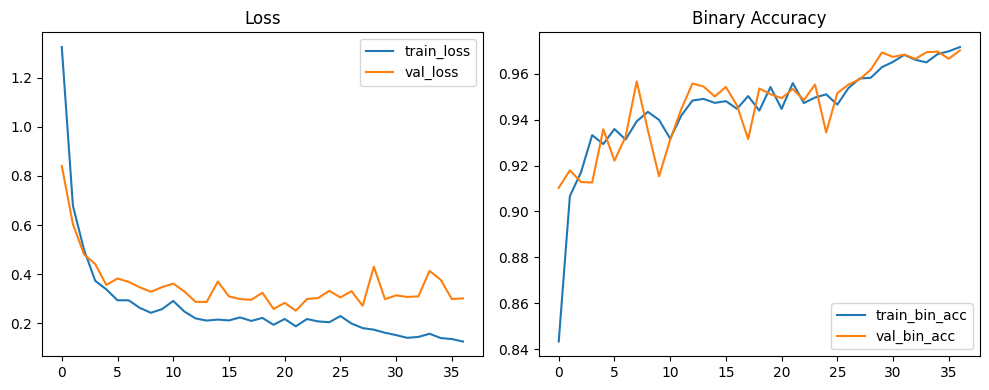

In [11]:
### 11) Callbacks y Entrenamiento
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model_frames.keras', save_best_only=True, monitor='val_loss', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, verbose=1)
]

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100, batch_size=8,  # batch_size aumentado a 8 por estabilidad; ajusta si falta memoria
    callbacks=callbacks, verbose=2
)

# Graficar curvas de entrenamiento
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(); plt.title('Loss')

plt.subplot(1,2,2)
if 'bin_acc' in history.history:
    plt.plot(history.history['bin_acc'], label='train_bin_acc')
    plt.plot(history.history['val_bin_acc'], label='val_bin_acc')
    plt.legend(); plt.title('Binary Accuracy')
plt.tight_layout()
plt.show()


In [12]:
### 12) Evaluación global y búsqueda de umbral por etiqueta
y_pred_prob = model.predict(X_val_scaled)  # shape (n_videos, frames, labels)

# Encontrar mejor umbral por etiqueta (en val) usando F1
best_thresholds = np.zeros(num_labels)
for i in range(num_labels):
    y_true = y_val[:,:,i].flatten()
    probs = y_pred_prob[:,:,i].flatten()
    best_f1 = -1
    best_t = 0.5
    for t in np.linspace(0.1, 0.9, 17):
        preds = (probs >= t).astype(int)
        f = f1_score(y_true, preds, zero_division=0)
        if f > best_f1:
            best_f1 = f; best_t = t
    best_thresholds[i] = best_t
    print(f"Etiqueta {error_cols[i]}: best threshold={best_t:.2f}, F1={best_f1:.3f}")

print("Umbrales por etiqueta:", best_thresholds)


4/4 [==============================] - 2s 342ms/step
Etiqueta giro_incompleto: best threshold=0.90, F1=0.603
Etiqueta pierna_patea_flexionada: best threshold=0.90, F1=0.623
Etiqueta pierna_base_flexionada: best threshold=0.90, F1=0.604
Etiqueta pie_sin_borde_externo: best threshold=0.90, F1=0.589
Etiqueta preparacion_incompleta: best threshold=0.90, F1=0.472
Etiqueta recogida_incompleta: best threshold=0.90, F1=0.594
Umbrales por etiqueta: [0.9 0.9 0.9 0.9 0.9 0.9]


Reporte de clasificación (frame a frame) con umbrales optimizados:

Etiqueta: giro_incompleto
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99     20410
         1.0       0.45      0.92      0.60       326

    accuracy                           0.98     20736
   macro avg       0.72      0.95      0.80     20736
weighted avg       0.99      0.98      0.98     20736


Etiqueta: pierna_patea_flexionada
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99     20492
         1.0       0.47      0.93      0.62       244

    accuracy                           0.99     20736
   macro avg       0.73      0.96      0.81     20736
weighted avg       0.99      0.99      0.99     20736


Etiqueta: pierna_base_flexionada
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99     20526
         1.0       0.47      0.83      0.60       210

    accuracy       

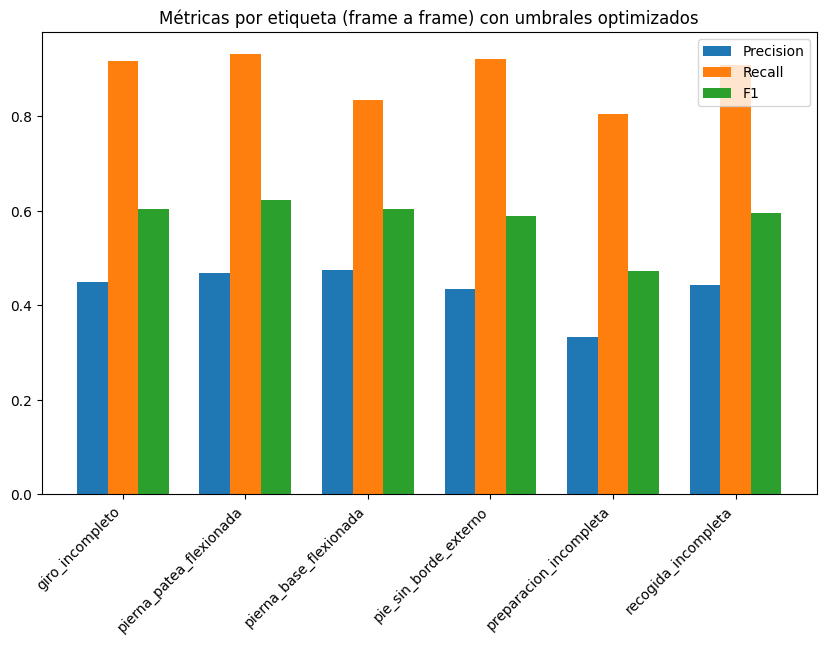

In [13]:
### 13) Reporte de clasificación usando los umbrales optimizados
y_pred = np.zeros_like(y_pred_prob, dtype=int)
for i in range(num_labels):
    y_pred[:,:,i] = (y_pred_prob[:,:,i] >= best_thresholds[i]).astype(int)

print("Reporte de clasificación (frame a frame) con umbrales optimizados:")
for i, label in enumerate(error_cols):
    print(f"\nEtiqueta: {label}")
    print(classification_report(y_val[:,:,i].flatten(), y_pred[:,:,i].flatten(), zero_division=0))

# Calcular y plotear precision/recall/f1 por etiqueta
precisions, recalls, f1s = [], [], []
for i in range(num_labels):
    y_true = y_val[:,:,i].flatten()
    y_pred_flat = y_pred[:,:,i].flatten()
    precisions.append(precision_score(y_true, y_pred_flat, zero_division=0))
    recalls.append(recall_score(y_true, y_pred_flat, zero_division=0))
    f1s.append(f1_score(y_true, y_pred_flat, zero_division=0))

x = np.arange(len(error_cols))
width = 0.25
plt.figure(figsize=(10,6))
plt.bar(x - width, precisions, width, label='Precision')
plt.bar(x, recalls, width, label='Recall')
plt.bar(x + width, f1s, width, label='F1')
plt.xticks(x, error_cols, rotation=45, ha='right')
plt.legend()
plt.title('Métricas por etiqueta (frame a frame) con umbrales optimizados')
plt.show()


In [14]:
### 14) Guardar modelo entrenado
model.save("modelo_lstm_frames.keras")
print("✅ Modelo guardado correctamente en formato .keras")


✅ Modelo guardado correctamente en formato .keras


In [1]:
masked_output = layers.Masking(mask_value=0.0)(input_seq)
print(masked_output._keras_mask)

NameError: name 'layers' is not defined